# Main Figure Revision

In [69]:
from pathlib import Path
import importlib
import sys

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parents[1]

pkg_root = repo_root / "data_synthesis"
if str(pkg_root) not in sys.path:
    sys.path.insert(0, str(pkg_root))

import src.figure4_neighborhood as figure4_neighborhood
figure4_neighborhood = importlib.reload(figure4_neighborhood)

import src.main_figures_revision as figrev
figrev = importlib.reload(figrev)
from IPython.display import display

datasets, summary = figrev.initialize_datasets()
print(
    f"Run mode: {figrev.RUN_MODE} | CVAE_EPOCHS={figrev.CVAE_EPOCHS}, "
    f"AUC_REPEATS={figrev.AUC_REPEATS}, TSTR_REPEATS={figrev.TSTR_REPEATS}, "
    f"ABLATION_REPEATS={figrev.ABLATION_REPEATS}, NOISE_REPEATS={figrev.NOISE_REPEATS}"
)
display(summary)


Run mode: final | CVAE_EPOCHS=200, AUC_REPEATS=50, TSTR_REPEATS=20, ABLATION_REPEATS=20, NOISE_REPEATS=5


,dataset,samples,features,class_0,class_1
0,HIV,91,63,23,68
1,Breast Cancer,569,30,212,357
2,Diabetes,768,8,500,268


## Cached Compute Helpers


In [70]:
display(figrev.cache_status())


,name,path,exists,readable,error
0,auc_runs,C:\Users\tonyt\Desktop\distinguishable_data\da...,True,True,
1,metric_table,C:\Users\tonyt\Desktop\distinguishable_data\da...,True,True,
2,ablation_df,C:\Users\tonyt\Desktop\distinguishable_data\da...,True,True,
3,noise_df,C:\Users\tonyt\Desktop\distinguishable_data\da...,True,True,


## Figure 2. PCA


Epoch    1 | train loss=59.4345 recon=59.3622 kl=0.1446 | val loss=78.4132 recon=78.3381 kl=0.1501
Epoch   10 | train loss=55.0814 recon=54.5651 kl=1.0327 | val loss=75.1556 recon=74.4211 kl=1.4690
Epoch   20 | train loss=49.5437 recon=46.3646 kl=6.3583 | val loss=59.7132 recon=57.2741 kl=4.8782
Epoch   30 | train loss=37.0336 recon=35.2526 kl=3.5620 | val loss=55.3492 recon=52.8178 kl=5.0628
Epoch   40 | train loss=35.7443 recon=31.5312 kl=8.4264 | val loss=53.4445 recon=48.9844 kl=8.9201
Epoch   50 | train loss=33.3516 recon=29.9936 kl=6.7162 | val loss=48.4559 recon=44.0604 kl=8.7910
Epoch   60 | train loss=33.5782 recon=29.7126 kl=7.7312 | val loss=47.5115 recon=43.3358 kl=8.3514
Epoch   70 | train loss=25.4368 recon=21.6556 kl=7.5625 | val loss=49.1987 recon=44.7192 kl=8.9590
Epoch   80 | train loss=27.3788 recon=22.9788 kl=8.8000 | val loss=46.1841 recon=41.4502 kl=9.4678
Epoch   90 | train loss=26.5942 recon=21.7606 kl=9.6673 | val loss=46.5686 recon=41.9486 kl=9.2398
Epoch  100

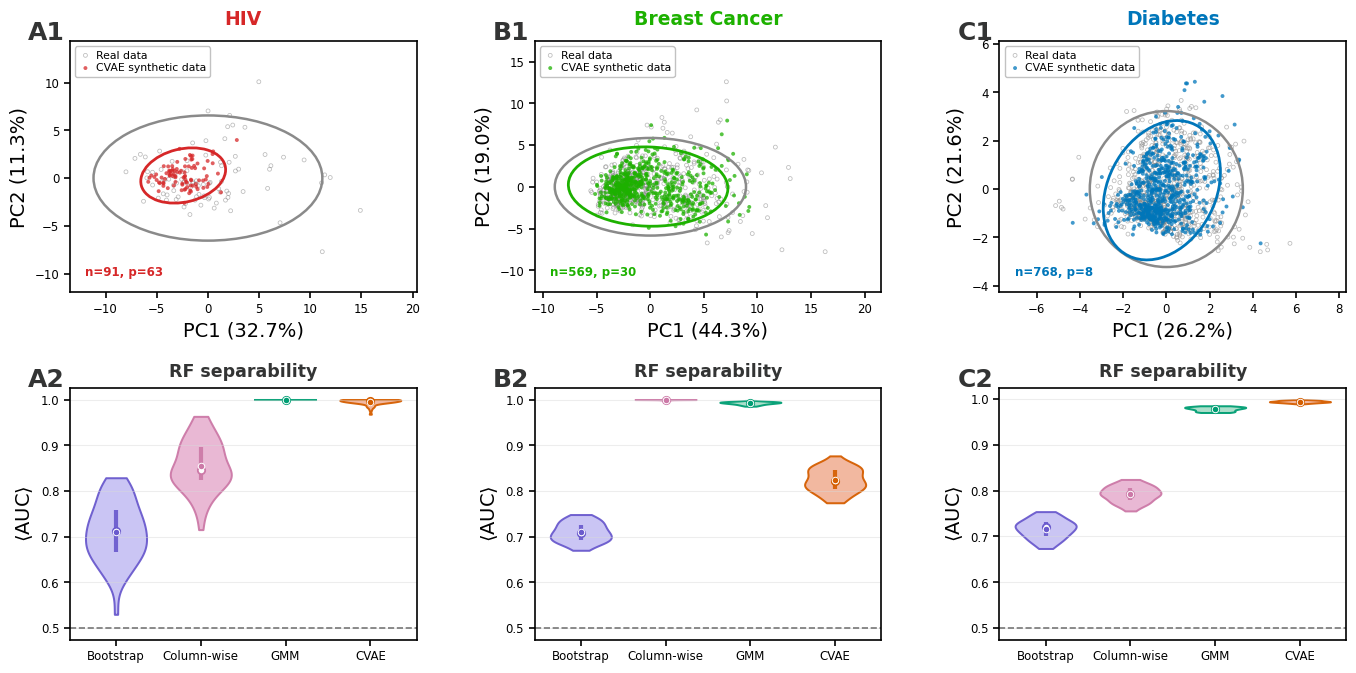

In [71]:
auc_runs = figrev.get_auc_runs(force=False)
fig2_6 = figrev.plot_figure2_six_panel(auc_runs)
figrev.display_figure_once(fig2_6)


[figure4] HIV - Bootstrap
[figure4] HIV - Column-wise
[figure4] HIV - GMM
[figure4] HIV - CVAE
Epoch    1 | train loss=59.4345 recon=59.3622 kl=0.1446 | val loss=78.4132 recon=78.3381 kl=0.1501
Epoch   10 | train loss=55.0814 recon=54.5651 kl=1.0327 | val loss=75.1556 recon=74.4211 kl=1.4690
Epoch   20 | train loss=49.5437 recon=46.3646 kl=6.3583 | val loss=59.7132 recon=57.2741 kl=4.8782
Epoch   30 | train loss=37.0336 recon=35.2526 kl=3.5620 | val loss=55.3492 recon=52.8178 kl=5.0628
Epoch   40 | train loss=35.7443 recon=31.5312 kl=8.4264 | val loss=53.4445 recon=48.9844 kl=8.9201
Epoch   50 | train loss=33.3516 recon=29.9936 kl=6.7162 | val loss=48.4559 recon=44.0604 kl=8.7910
Epoch   60 | train loss=33.5782 recon=29.7126 kl=7.7312 | val loss=47.5115 recon=43.3358 kl=8.3514
Epoch   70 | train loss=25.4368 recon=21.6556 kl=7.5625 | val loss=49.1987 recon=44.7192 kl=8.9590
Epoch   80 | train loss=27.3788 recon=22.9788 kl=8.8000 | val loss=46.1841 recon=41.4502 kl=9.4678
Epoch   90 | t

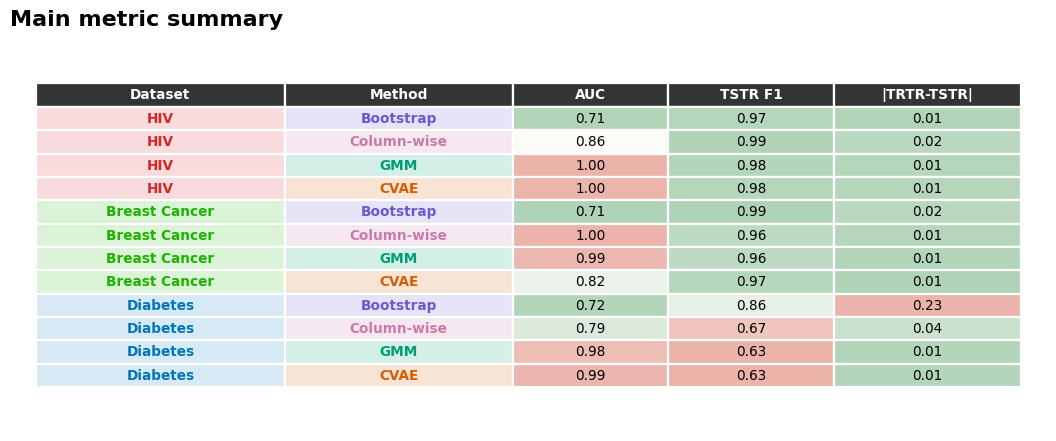

,Dataset,Method,AUC,TSTR F1,|TRTR-TSTR|
0,HIV,Bootstrap,0.71,0.97,0.01
1,HIV,Column-wise,0.86,0.99,0.02
2,HIV,GMM,1.00,0.98,0.01
3,HIV,CVAE,1.00,0.98,0.01
4,Breast Cancer,Bootstrap,0.71,0.99,0.02
5,Breast Cancer,Column-wise,1.00,0.96,0.01
6,Breast Cancer,GMM,0.99,0.96,0.01
7,Breast Cancer,CVAE,0.82,0.97,0.01
8,Diabetes,Bootstrap,0.72,0.86,0.23
9,Diabetes,Column-wise,0.79,0.67,0.04


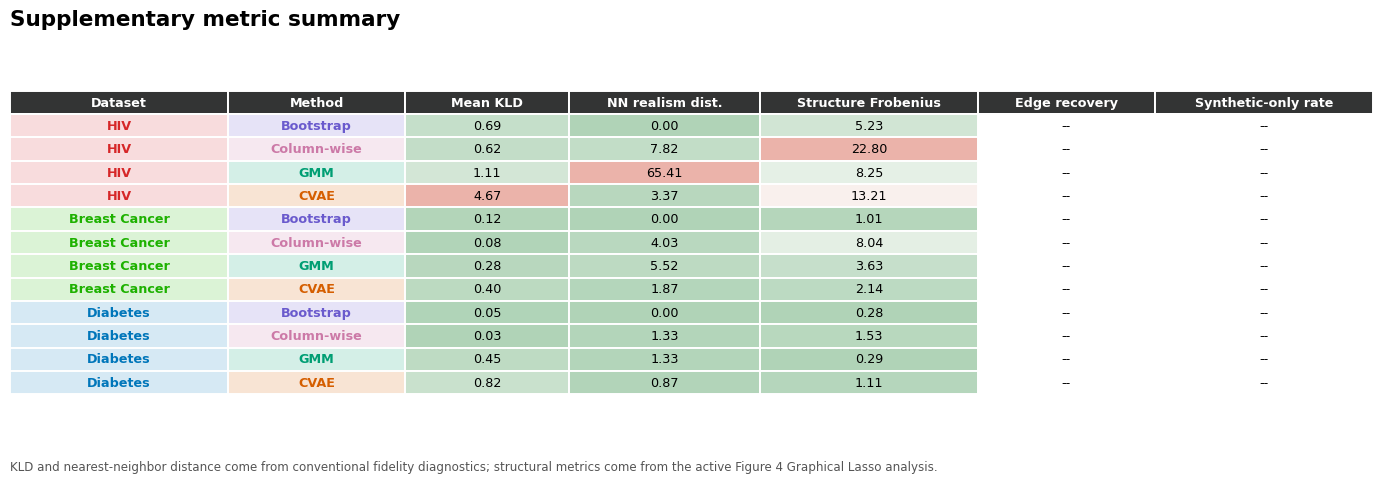

,Dataset,Method,Mean KLD,NN realism dist.,Structure Frobenius,Edge recovery,Synthetic-only rate
0,HIV,Bootstrap,0.69,0.00,5.23,--,--
1,HIV,Column-wise,0.62,7.82,22.80,--,--
2,HIV,GMM,1.11,65.41,8.25,--,--
3,HIV,CVAE,4.67,3.37,13.21,--,--
4,Breast Cancer,Bootstrap,0.12,0.00,1.01,--,--
5,Breast Cancer,Column-wise,0.08,4.03,8.04,--,--
6,Breast Cancer,GMM,0.28,5.52,3.63,--,--
7,Breast Cancer,CVAE,0.40,1.87,2.14,--,--
8,Diabetes,Bootstrap,0.05,0.00,0.28,--,--
9,Diabetes,Column-wise,0.03,1.33,1.53,--,--


In [72]:
metric_table = figrev.get_metric_table(force=False)
main_metric_summary_fig, main_metric_summary_table = figrev.plot_main_metric_summary_table(metric_table)
structure_metrics_for_supp = figrev.compute_figure4_frobenius_summary(datasets)
supp_metric_summary_fig, supp_metric_summary_table = figrev.plot_supplementary_metric_table(metric_table, structure_metrics_for_supp)
figrev.display_figure_once(main_metric_summary_fig)
display(main_metric_summary_table)
figrev.display_figure_once(supp_metric_summary_fig)
display(supp_metric_summary_table)


In [73]:
supp_metric_summary_table.to_latex(
    "supp_metric_summary_table.tex",
    index=False,
    float_format="%.3f",
    caption="Summary of synthetic data quality metrics across datasets and methods.",
    label="tab:supp_metric_summary",
)


## Figure 4: HIV Conditional-Dependence Structure

Question: do synthetic HIV datasets preserve the same conditional-dependency structure as the real HIV dataset?

Figure 4 uses Graphical Lasso rather than ordinary pairwise correlation. Graphical Lasso estimates a sparse precision matrix, where off-diagonal entries encode conditional relationships among features. The main Figure 4 block starts with HIV, followed by supplementary Breast Cancer and Diabetes panels using the same plot sequence.

`precision-matrix discrepancy = ||Theta_real - Theta_synthetic||_F`

Per-dataset readout:

- **A-K. Combined edge-status and t-SNE summary** for the dataset.
- **Merged A-D. Large edge-status matrix** for the same dataset.
- **I-K all-dataset summary** keeps the preservation/lost/synthetic-only t-SNE readouts visible across HIV, Breast Cancer, and Diabetes.


## Figure 4 Helpers


In [74]:
figure4_supp_real_data, figure4_supp_synthetic_data, figure4_supp_feature_names = figrev._get_figure4_precision_inputs()


### HIV Edge-Status Reading Example

This restores the explanatory example figure from the older supplemental workflow: a small edge-status matrix window on the left and the selected feature row converted into a graph on the right.


In [ ]:
figure4_supplemental_results, figure4_supplemental_metrics = figrev.build_figure4_supplemental_figures_inline(
    real_data=figure4_supp_real_data,
    synthetic_data=figure4_supp_synthetic_data,
    feature_names=figure4_supp_feature_names,
    seed=figrev.SEED,
)
fig4_edge_status_examples = figure4_supplemental_results["HIV examples"]

figrev.display_result_once(fig4_edge_status_examples)

display(
    figure4_supplemental_metrics
    .query("figure_dataset == 'HIV examples'")
    .sort_values(["figure_dataset", "dataset", "method"])
)


### HIV Figure 4: A-K, Merged A-D, and All-Dataset I-K


In [ ]:
fig4_result = figrev.plot_figure4_combined_edge_status("HIV")
fig4_supp_hiv = fig4_result
fig4_hiv_edge_status = figrev.plot_figure4_edge_status("HIV")
corr_summary = fig4_result.metrics

fig4_cluster_summary = figrev.plot_figure4_cluster_summary_all_datasets()
fig4_tsne_group_summaries = fig4_cluster_summary.group_summary

figrev.display_result_once(fig4_result)
figrev.display_result_once(fig4_hiv_edge_status)
figrev.display_result_once(fig4_cluster_summary)
display(corr_summary.sort_values(["dataset", "method"]))
display(fig4_result.feature_index)
display(fig4_tsne_group_summaries[["dataset", "panel", "mode", "cluster_id", "method", "n_features", "center_x", "center_y"]])


### HIV Figure 4 Panel E: Structural Deviation


In [ ]:
fig4_panel_e = figrev.plot_figure4_metric_summary(
    corr_summary,
    dataset_order=["HIV"],
    method_order=figrev.METHOD_ORDER,
)
figrev.display_figure_once(fig4_panel_e)


## Supplementary

Featuring Breast Cancer and Diabetes.


### Breast Cancer Figure 4: A-K and Merged A-D


In [ ]:
fig4_bc_result = figure4_supplemental_results["Breast Cancer"]
fig4_bc_edge_status = figrev.plot_figure4_edge_status("Breast Cancer")

figrev.display_result_once(fig4_bc_result)
figrev.display_result_once(fig4_bc_edge_status)


### Diabetes Figure 4: A-K and Merged A-D


In [ ]:
fig4_diabetes_result = figure4_supplemental_results["Diabetes"]
fig4_diabetes_edge_status = figrev.plot_figure4_edge_status("Diabetes")

figrev.display_result_once(fig4_diabetes_result)
figrev.display_result_once(fig4_diabetes_edge_status)


### Supplementary Figure 4 Metrics


In [ ]:
display(
    figure4_supplemental_metrics
    [figure4_supplemental_metrics["figure_dataset"].isin(["Breast Cancer", "Diabetes"])]
    .sort_values(["figure_dataset", "dataset", "method"])
)


## Figure 5: Noise Sensitivity

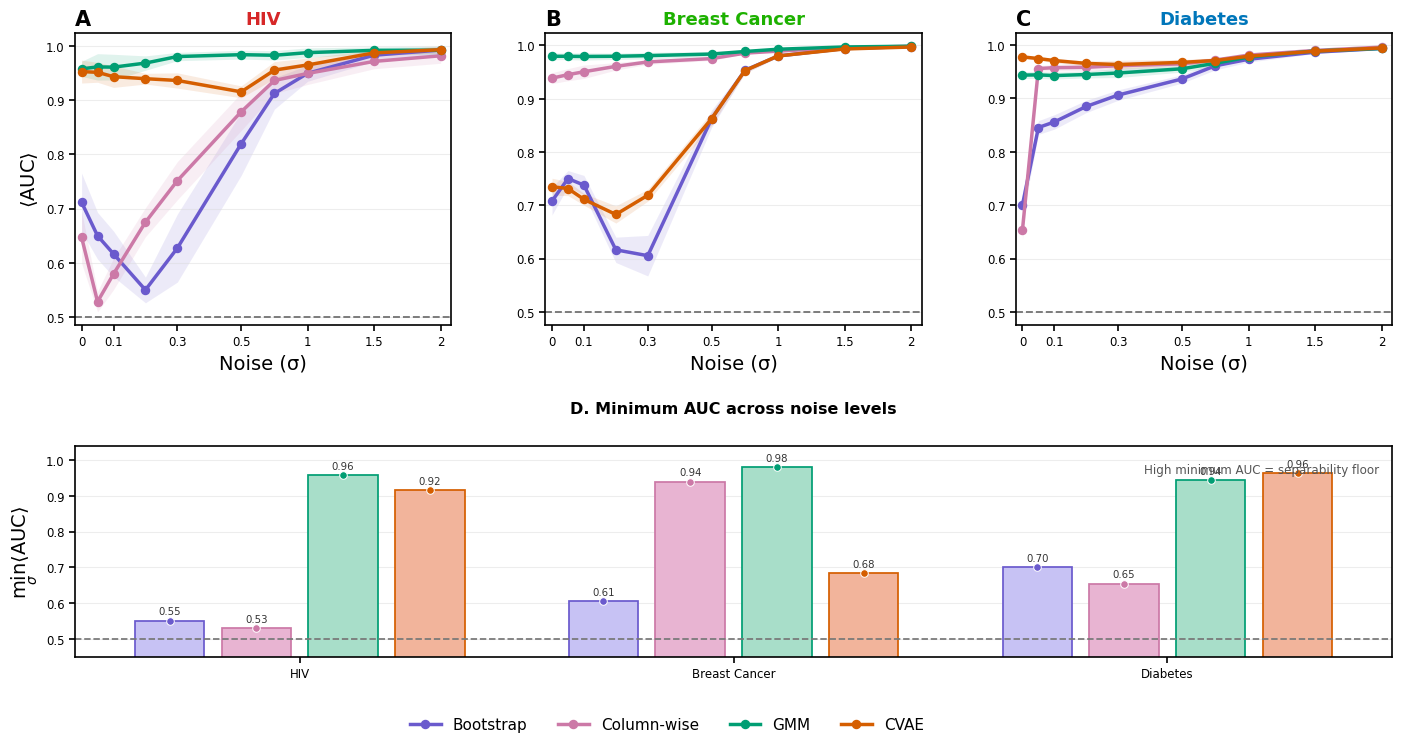

,dataset,method,min_auc
0,Breast Cancer,Bootstrap,0.605521
1,Breast Cancer,CVAE,0.682891
2,Breast Cancer,Column-wise,0.938697
3,Breast Cancer,GMM,0.979362
4,Diabetes,Bootstrap,0.700590
5,Diabetes,CVAE,0.963489
6,Diabetes,Column-wise,0.653512
7,Diabetes,GMM,0.942871
8,HIV,Bootstrap,0.550469
9,HIV,CVAE,0.915156


In [79]:
noise_df = figrev.get_noise_sensitivity(force=False)
fig5_noise, noise_auc_floor = figrev.plot_figure5_noise(noise_df)
figrev.display_figure_once(fig5_noise)
display(noise_auc_floor)


## Figure 6: Single Combined Reverse-Ablation Figure

This uses the all-dataset A-C function added to the outline notebook, and keeps the x-axis as percentage of top discriminator-ranked features removed so datasets with different numbers of features are comparable.


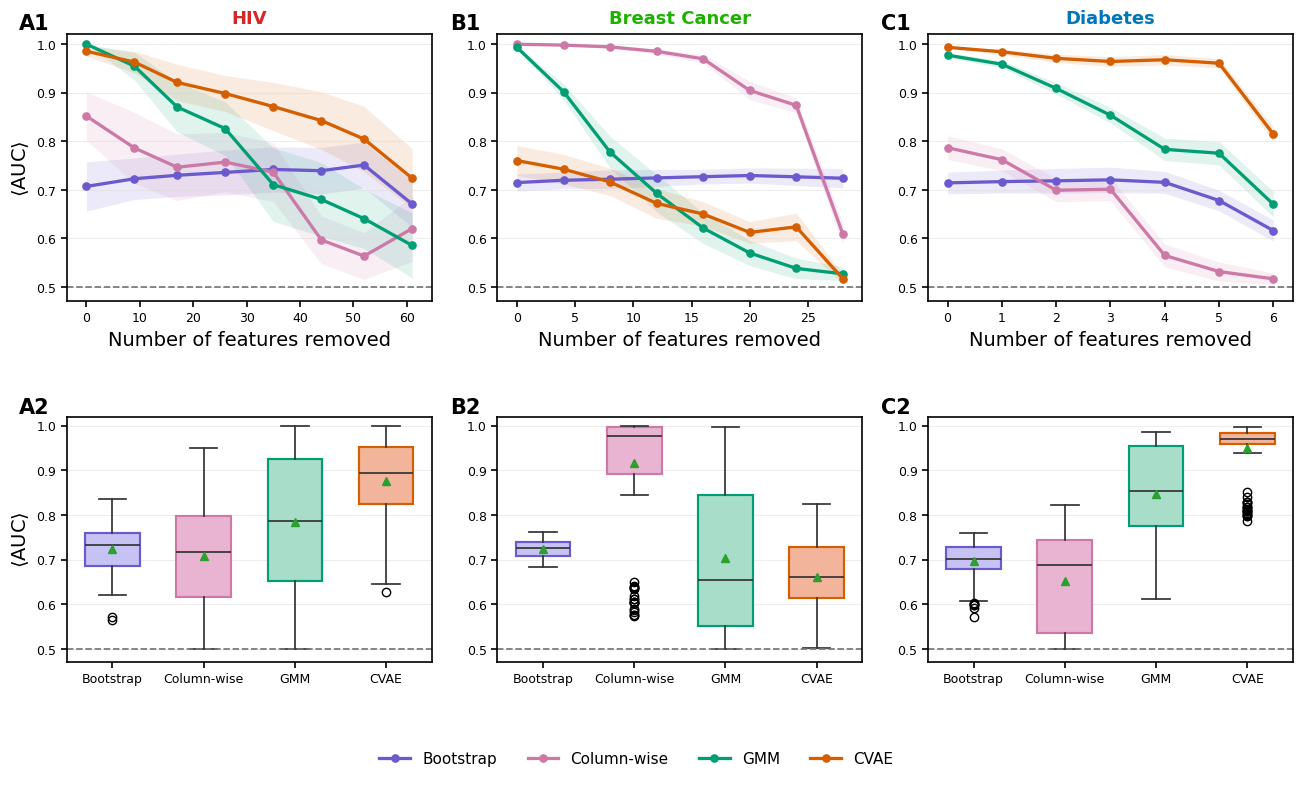

In [80]:
ablation_df = figrev.get_reverse_ablation(force=False)
fig6_ac = figrev.plot_figure6_ablation_all_datasets(ablation_df)
figrev.display_figure_once(fig6_ac)
